In [2]:
%pip install yfinance pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\comp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Fetching the Share Market Dataset
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
start_date = "2023-01-01"
end_date = "2025-03-01"

stock_data = yf.download(ticker, start=start_date, end=end_date)
stock_data.to_csv("AAPL_stock_data.csv")
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365669  126.629372  123.105873  124.887303   89113600
2023-01-05  123.046814  125.753411  122.790923  125.123513   80962700
2023-01-06  127.574181  128.233604  122.918839  124.021165   87754700
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800


In [4]:
print("Dataset Shape:", stock_data.shape)
print("\nBasic Statistics:")
print(stock_data.describe())

Dataset Shape: (541, 5)

Basic Statistics:
Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL          AAPL
count   541.000000  541.000000  541.000000  541.000000  5.410000e+02
mean    191.474863  193.041801  189.627698  191.203432  5.778049e+07
std      29.755455   29.988937   29.422897   29.757001  2.467663e+07
min     123.046814  125.753411  122.210234  124.021165  2.323470e+07
25%     171.063171  172.096830  169.255171  170.620399  4.464920e+07
50%     185.693741  186.968423  184.624039  185.918591  5.245640e+07
75%     221.266495  223.770074  218.936742  221.157212  6.475140e+07
max     257.612732  258.686881  256.230300  256.787255  3.186799e+08


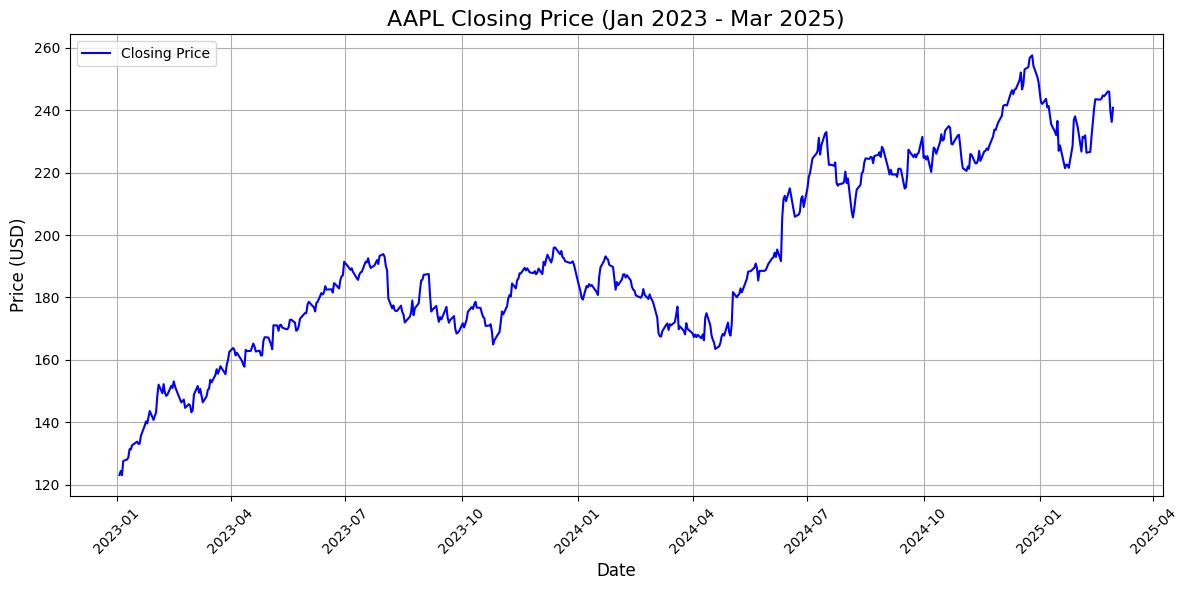

In [5]:
# Line Plot of Closing Price
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Closing Price', color='blue')
plt.title('AAPL Closing Price (Jan 2023 - Mar 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Candlestick Chart
%pip install mplfinance

   ---------------------------------------- 0.0/75.0 kB ? eta -:--:--
   ---------------------------------------- 75.0/75.0 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\comp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


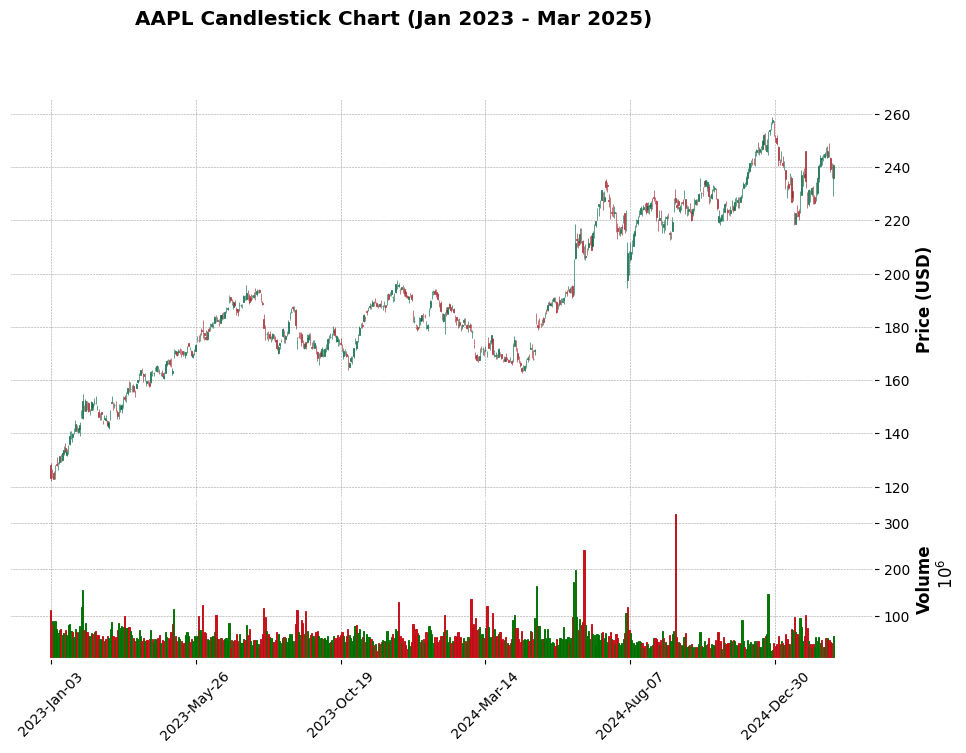

In [7]:
import mplfinance as mpf

# Flatten the column names
stock_data.columns = stock_data.columns.get_level_values(0)

mpf.plot(stock_data, type='candle', style='charles', 
         title='AAPL Candlestick Chart (Jan 2023 - Mar 2025)',
         ylabel='Price (USD)', volume=True, 
         ylabel_lower='Volume', figsize=(12, 8))

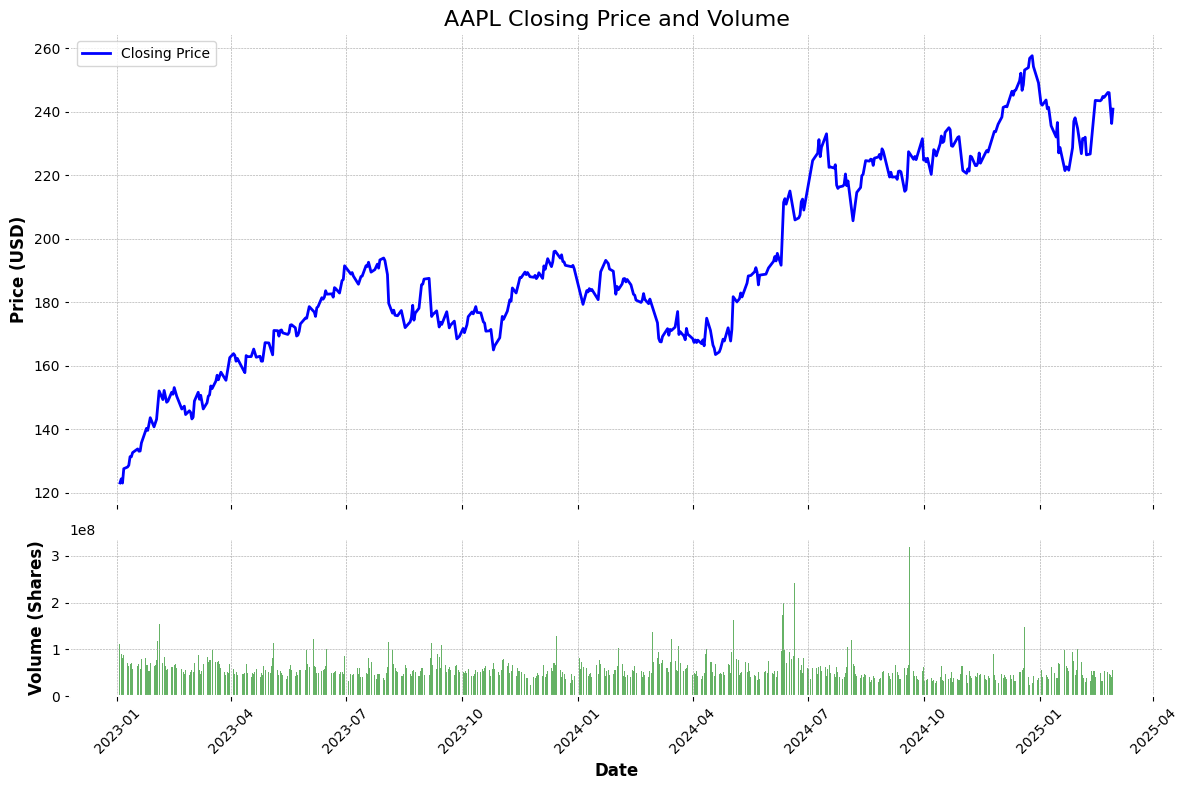

In [8]:
# Combined Price and Volume Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(stock_data.index, stock_data['Close'], label='Closing Price', color='blue')
ax1.set_title('AAPL Closing Price and Volume', fontsize=16)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.grid(True)
ax1.legend()
ax2.bar(stock_data.index, stock_data['Volume'], color='green', alpha=0.6)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume (Shares)', fontsize=12)
ax2.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

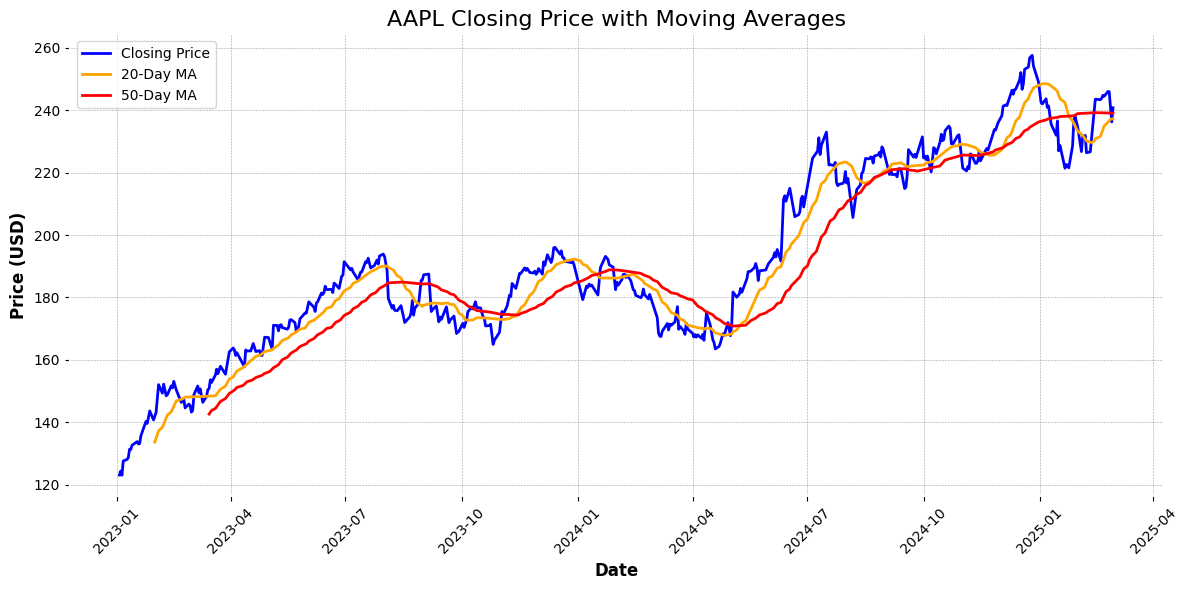

In [9]:
# Adding Moving Averages
stock_data['MA20'] = stock_data['Close'].rolling(window=20).mean()
stock_data['MA50'] = stock_data['Close'].rolling(window=50).mean()

plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Closing Price', color='blue')
plt.plot(stock_data.index, stock_data['MA20'], label='20-Day MA', color='orange')
plt.plot(stock_data.index, stock_data['MA50'], label='50-Day MA', color='red')
plt.title('AAPL Closing Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Saving Your Work
plt.savefig('AAPL_price_volume.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

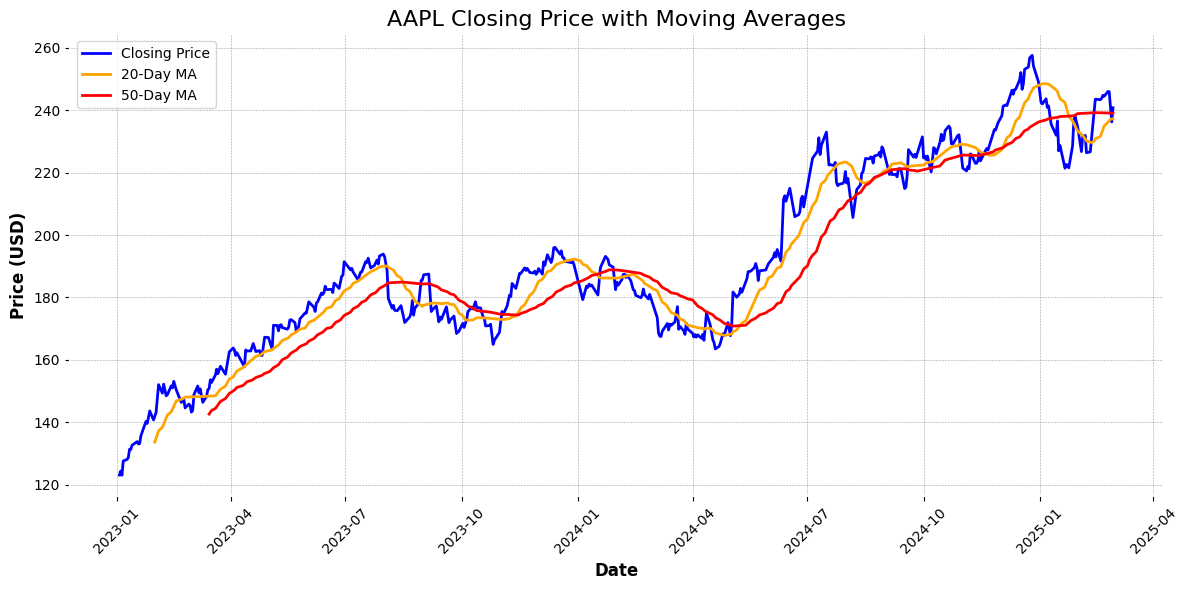

In [11]:
# Save the combined price and volume plot
fig.savefig('AAPL_closing_price_volume.png', dpi=300, bbox_inches='tight')

# Save the moving averages plot
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Closing Price', color='blue')
plt.plot(stock_data.index, stock_data['MA20'], label='20-Day MA', color='orange')
plt.plot(stock_data.index, stock_data['MA50'], label='50-Day MA', color='red')
plt.title('AAPL Closing Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('AAPL_closing_price_moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()